# 🌾 Crop Recommendation System
## Notebook 1: Data Collection, Preprocessing & EDA

**Team Members:**
- MUHAMMED SHAHID S *(Data & EDA Lead)*
- ANUSREE S *(Modelling & Explainability Lead)*
- ABIKRISHNAN M S *(Deployment & Documentation Lead)*

---

## 📌 Stage 1: Problem Definition & Literature Review

### Problem Statement
Agriculture is one of the most vital sectors in India, yet farmers often lack access to scientific guidance on crop selection. Choosing the wrong crop based on unsuitable soil or climate conditions leads to poor yield and financial loss.

This project builds a **Crop Recommendation System** that uses soil nutrient values (Nitrogen, Phosphorus, Potassium), temperature, humidity, pH, and rainfall to recommend the most suitable crop — using machine learning classification models.

### Objectives
- Analyse soil and climate features to understand their relationship with crop suitability
- Train and compare multi-class classifiers: Random Forest, KNN, Decision Tree
- Deploy an interactive web app for farmers using Streamlit

### Literature Review
1. **Pudumalar et al. (2017)** — Proposed a crop recommendation system using ensemble techniques on soil data, achieving high accuracy with Random Forest.
2. **Savla et al. (2015)** — Used KNN and Naive Bayes on agricultural datasets and found that soil pH and rainfall are the most significant predictors.
3. **Kulkarni & Srinivasan (2018)** — Demonstrated that multi-class classification using decision trees provides interpretable results suitable for real-world farmer usage.

---

## 📦 Stage 2: Data Collection & Understanding
### 2.1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


### 2.2 — Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("Crop_recommendation.csv")

print(f"Dataset shape: {df.shape}")
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
df.head(10)

Dataset shape: (2200, 8)
Total records: 2200
Total features: 8


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


### 2.3 — Dataset Information

In [3]:
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


### 2.4 — Statistical Summary

In [4]:
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe().round(2)

STATISTICAL SUMMARY


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


**Observations from Statistical Summary:**
- **N (Nitrogen):** ranges from 0 to 140 mg/kg, mean = 50.55
- **P (Phosphorus):** ranges from 5 to 145 mg/kg, mean = 53.36
- **K (Potassium):** ranges from 5 to 205 mg/kg, mean = 48.15
- **Temperature:** ranges from 8.83C to 43.68C, mean = 25.62C
- **Humidity:** ranges from 14.26% to 99.98%, mean = 71.48%
- **pH:** ranges from 3.50 to 9.94, mean = 6.47 (slightly acidic on average)
- **Rainfall:** ranges from 20.21mm to 298.56mm, mean = 103.46mm

### 2.5 — Target Variable: Class Distribution

In [5]:
# Count each crop
class_counts = df["label"].value_counts()
print("Crop class distribution:")
print(class_counts)
print(f"\nTotal unique crops: {df['label'].nunique()}")
print(f"Samples per crop: {class_counts.values[0]}")

Crop class distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Total unique crops: 22
Samples per crop: 100


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\208851845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label",


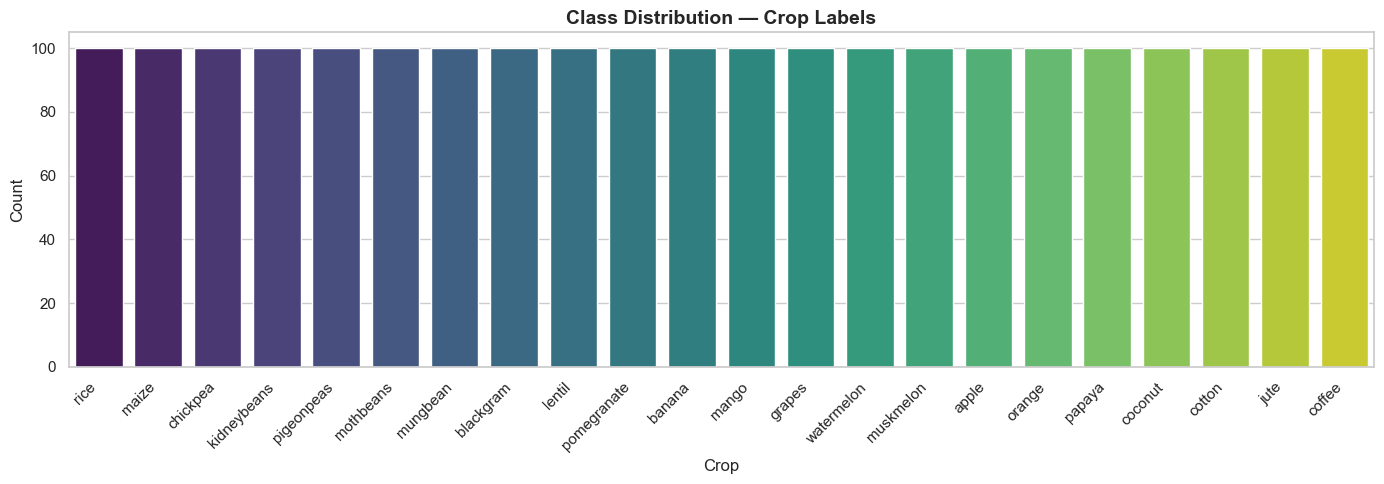

Dataset is perfectly balanced — 100 samples per crop


In [6]:
# Bar chart of class distribution
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x="label",
              order=df["label"].value_counts().index,
              palette="viridis")
plt.title("Class Distribution — Crop Labels", fontsize=14, fontweight="bold")
plt.xlabel("Crop", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("Dataset is perfectly balanced — 100 samples per crop")

---
## 🧹 Stage 3: Data Preprocessing & Cleaning
### 3.1 — Check for Missing Values

In [7]:
# Null value check
print("=" * 40)
print("MISSING VALUES PER COLUMN")
print("=" * 40)
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal missing values: {null_counts.sum()}")
print("No missing values found — dataset is complete")

MISSING VALUES PER COLUMN
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0
No missing values found — dataset is complete


### 3.2 — Check for Duplicate Records

In [8]:
# Duplicate check
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates == 0:
    print("No duplicate records found")
else:
    df = df.drop_duplicates()
    print(f"{duplicates} duplicates removed")

Total duplicate rows: 0
No duplicate records found


### 3.3 — Outlier Detection (Boxplots)

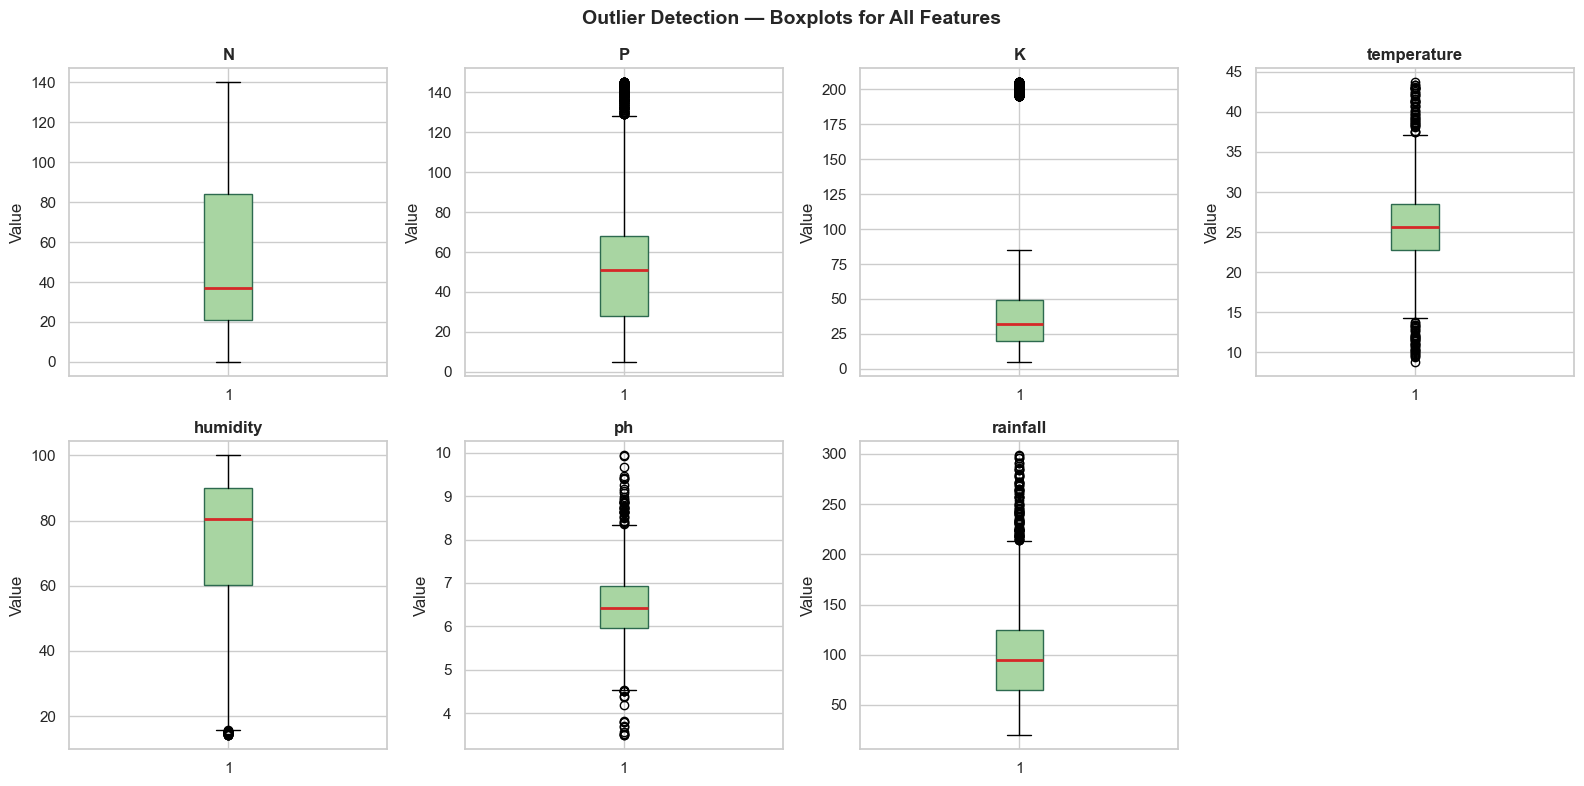

In [9]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].boxplot(df[feat], patch_artist=True,
                    boxprops=dict(facecolor="#a8d5a2", color="#2d6a4f"),
                    medianprops=dict(color="#d62828", linewidth=2))
    axes[i].set_title(feat, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Value")

axes[-1].set_visible(False)
plt.suptitle("Outlier Detection — Boxplots for All Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Preprocessing Summary:**
- No missing values detected across all 2,200 records
- No duplicate rows found
- Some outliers visible in K, humidity, and rainfall — these are **natural agricultural variations and are retained intentionally**, as they represent real farming conditions
- All features are numerical — no encoding needed for inputs
- Target label is categorical — will be encoded using LabelEncoder in the modelling notebook
- Dataset is perfectly balanced (100 samples x 22 crops = 2,200 rows)

---
## 📊 Stage 4: Exploratory Data Analysis (EDA)
### 4.1 — Feature Distributions (Histograms)

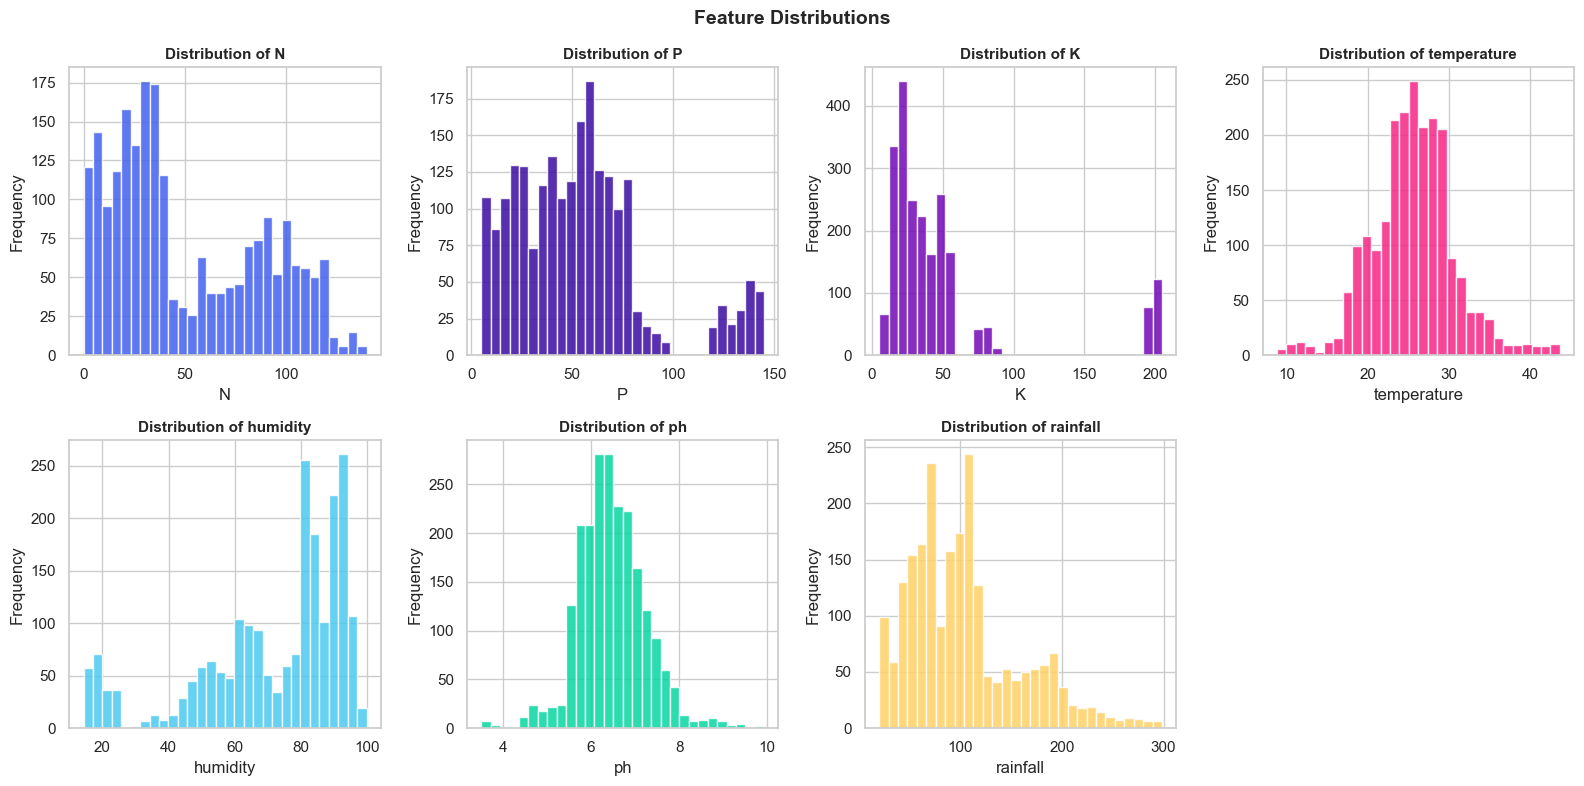

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colors = ["#4361ee","#3a0ca3","#7209b7","#f72585","#4cc9f0","#06d6a0","#ffd166"]

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, color=colors[i],
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Distribution of {feat}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frequency")

axes[-1].set_visible(False)
plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 — Correlation Heatmap

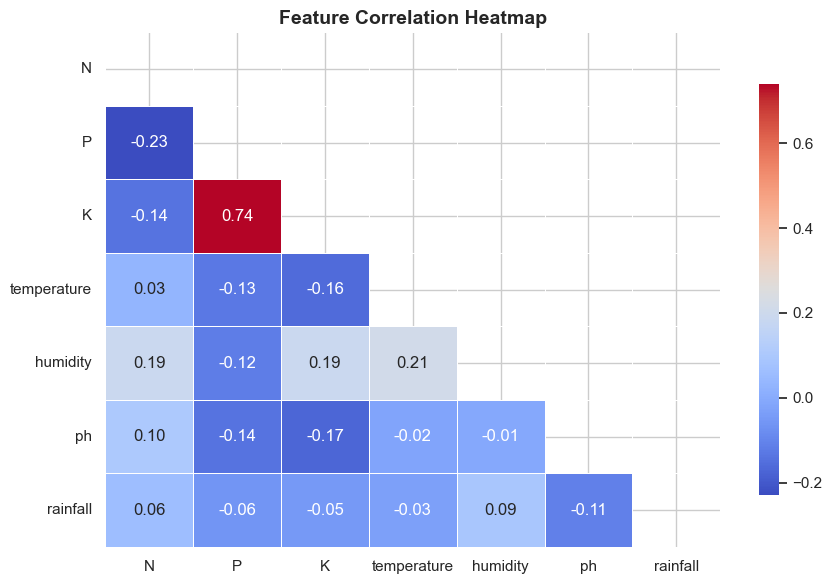

In [11]:
plt.figure(figsize=(9, 6))
corr = df[features].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Correlation Observations:**
- N and K show a moderate positive correlation — both are primary macronutrients often applied together
- Temperature and humidity show a slight negative correlation
- Most features are weakly correlated with each other — each contributes independent information
- pH shows very low correlation with all other features, confirming it is an independent soil property

### 4.3 — Violin Plots: Feature Distribution per Crop

C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


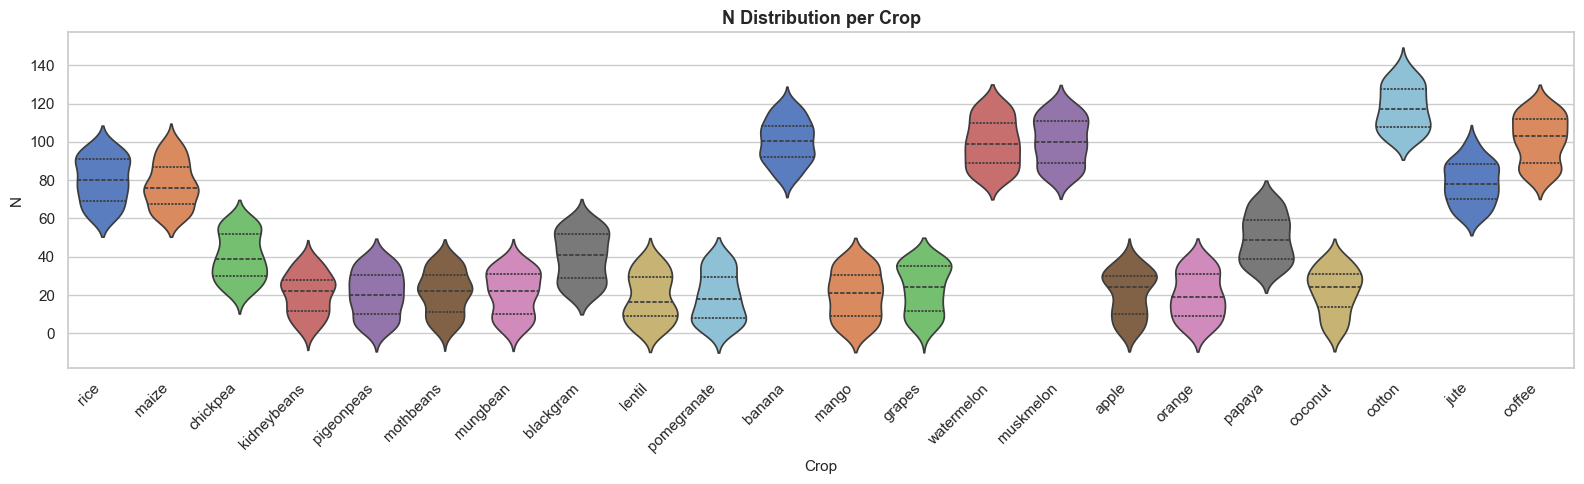

------------------------------------------------------------


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


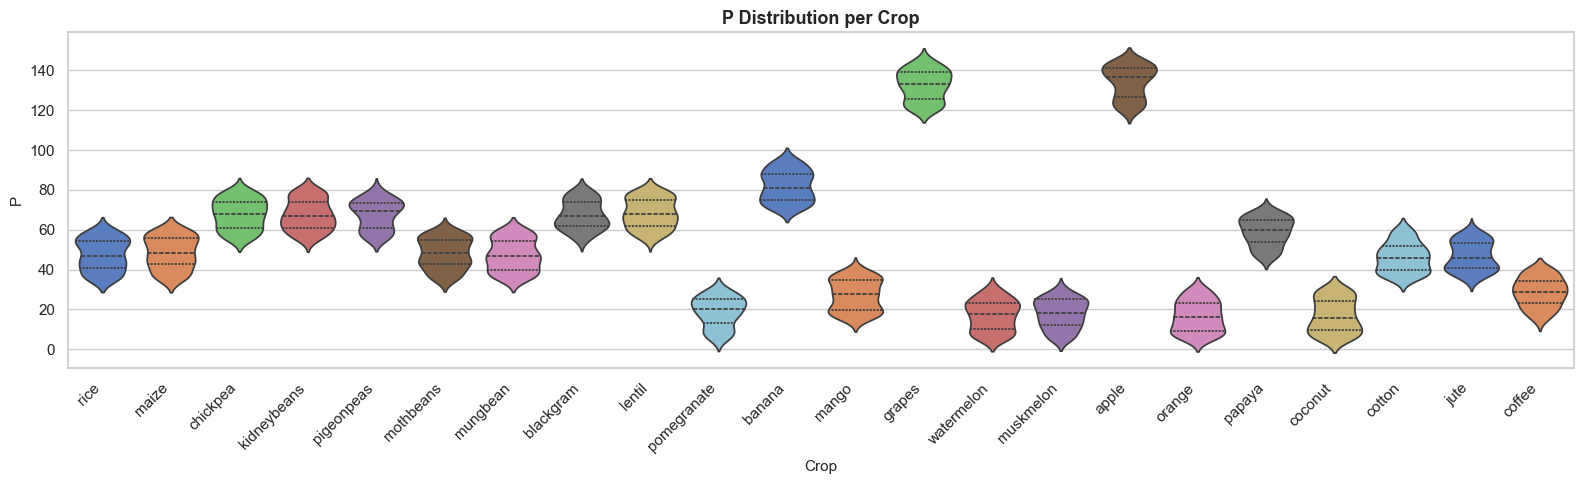

------------------------------------------------------------


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


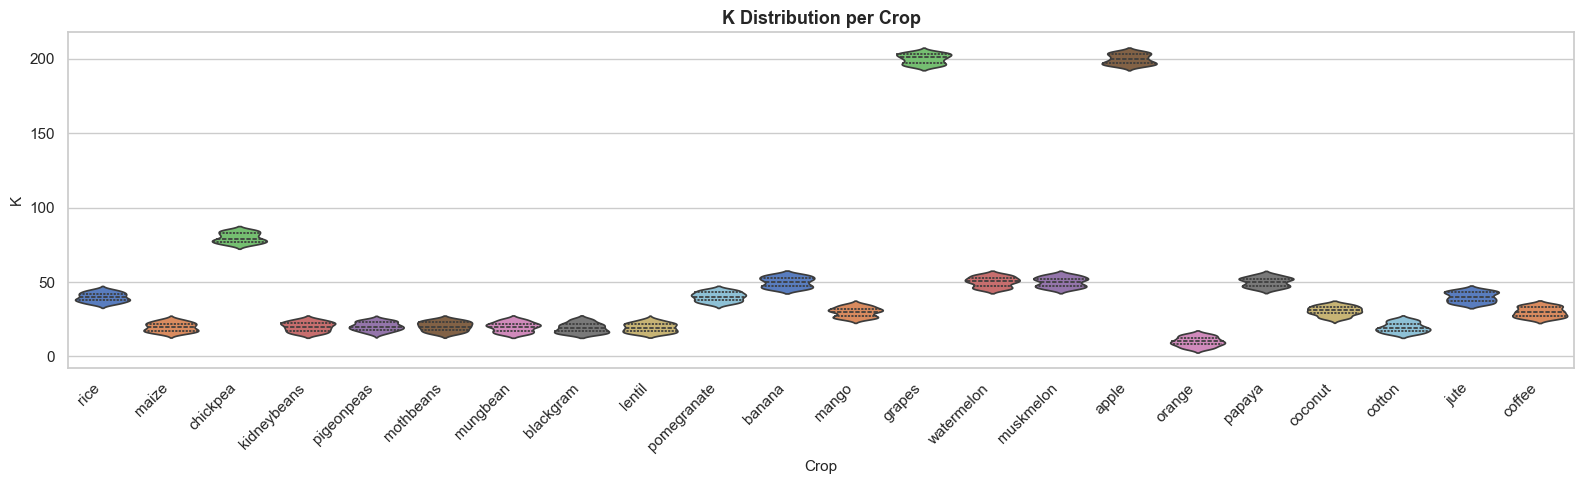

------------------------------------------------------------


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


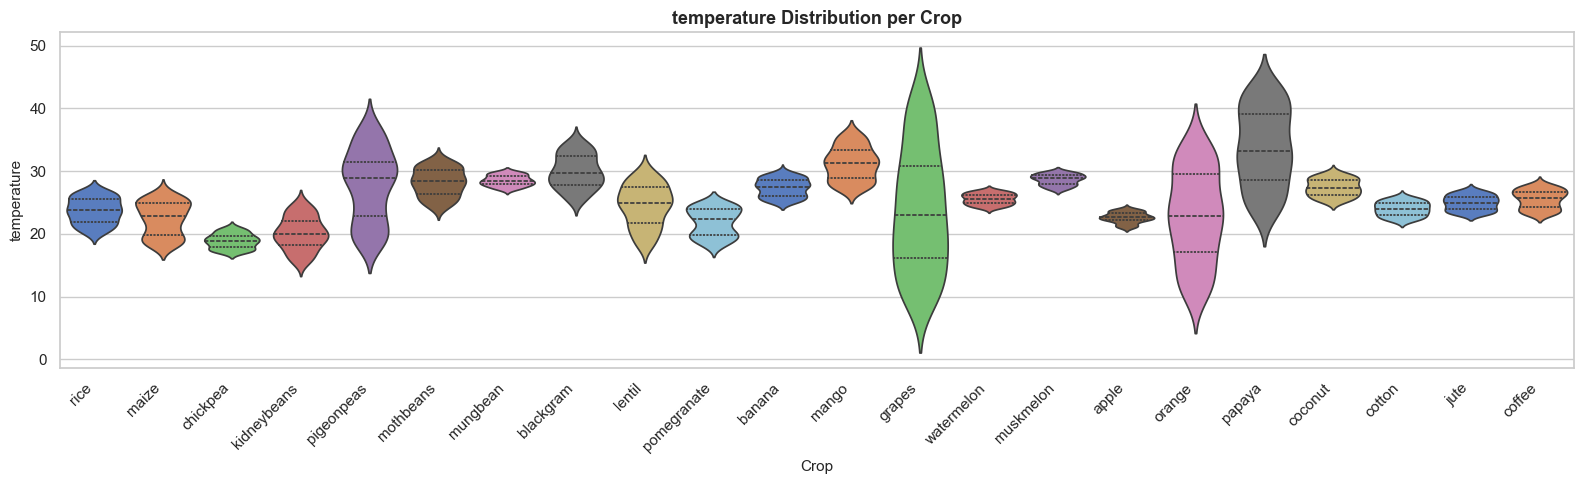

------------------------------------------------------------


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


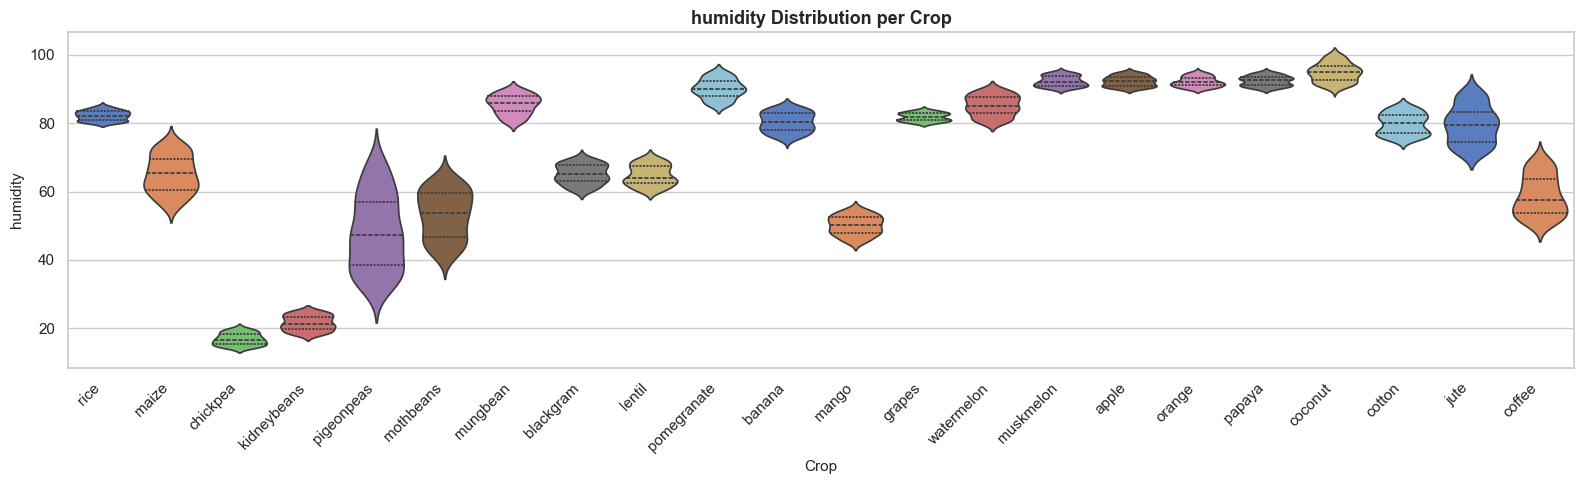

------------------------------------------------------------


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


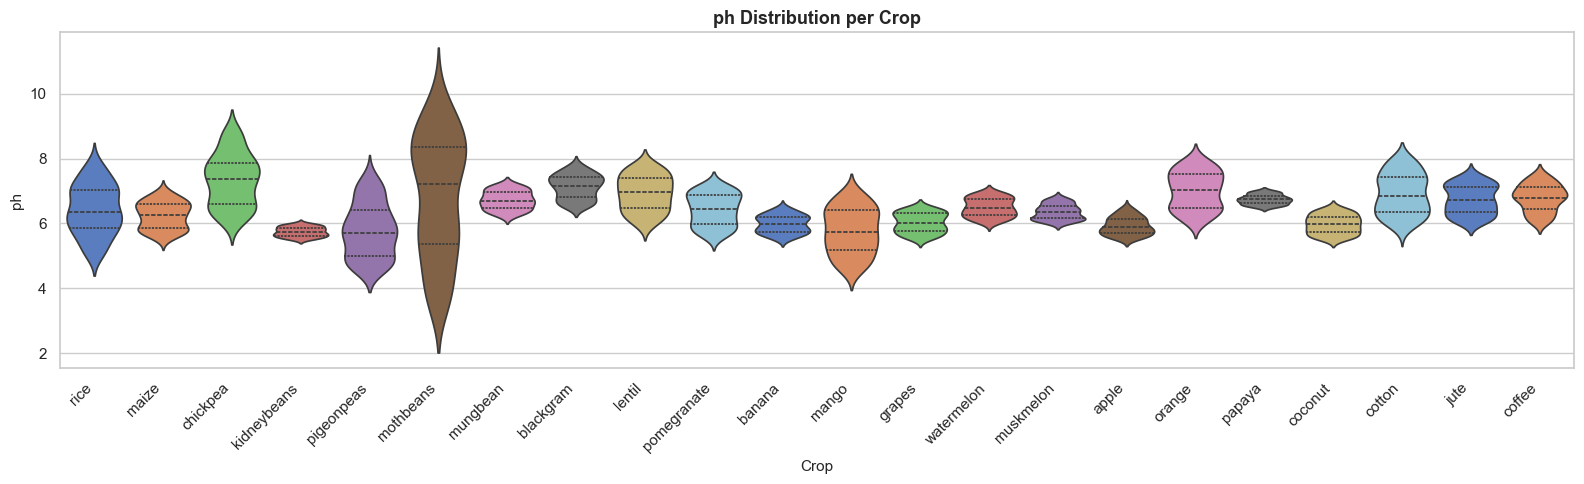

------------------------------------------------------------


C:\Users\shemi\AppData\Local\Temp\ipykernel_10700\2641300131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y=feat,


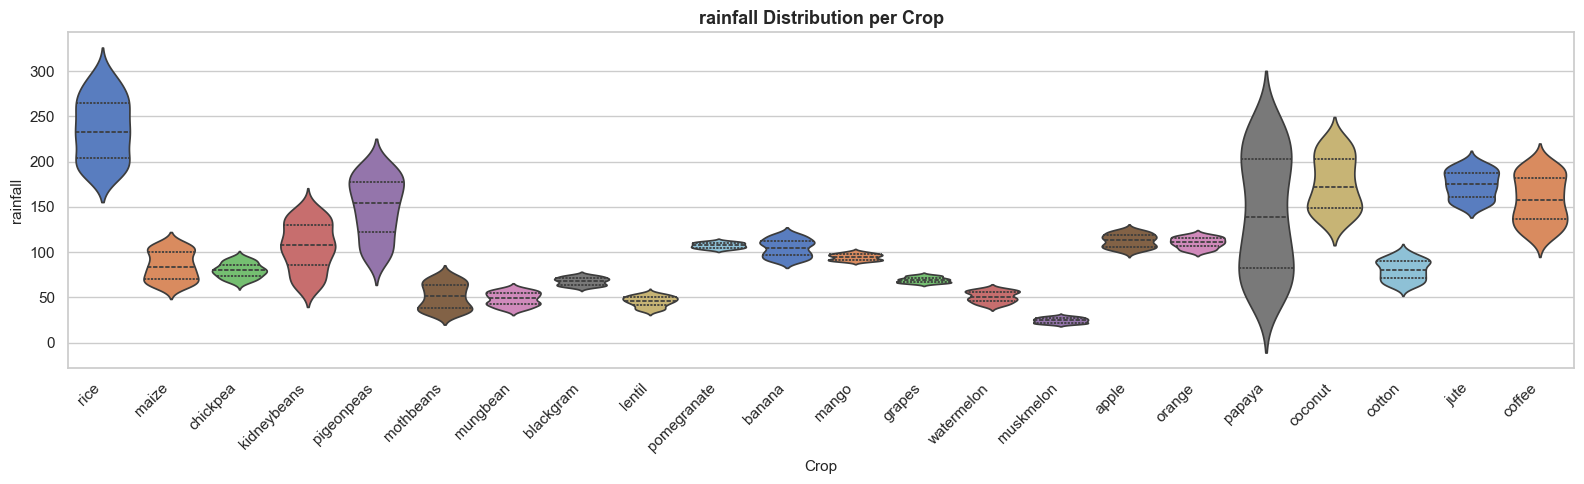

------------------------------------------------------------


In [12]:
for feat in features:
    plt.figure(figsize=(16, 5))
    sns.violinplot(data=df, x="label", y=feat,
                   palette="muted", inner="quartile")
    plt.title(f"{feat} Distribution per Crop",
              fontsize=13, fontweight="bold")
    plt.xlabel("Crop", fontsize=11)
    plt.ylabel(feat, fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print("-" * 60)

### 4.4 — Average Feature Values per Crop (Heatmap)

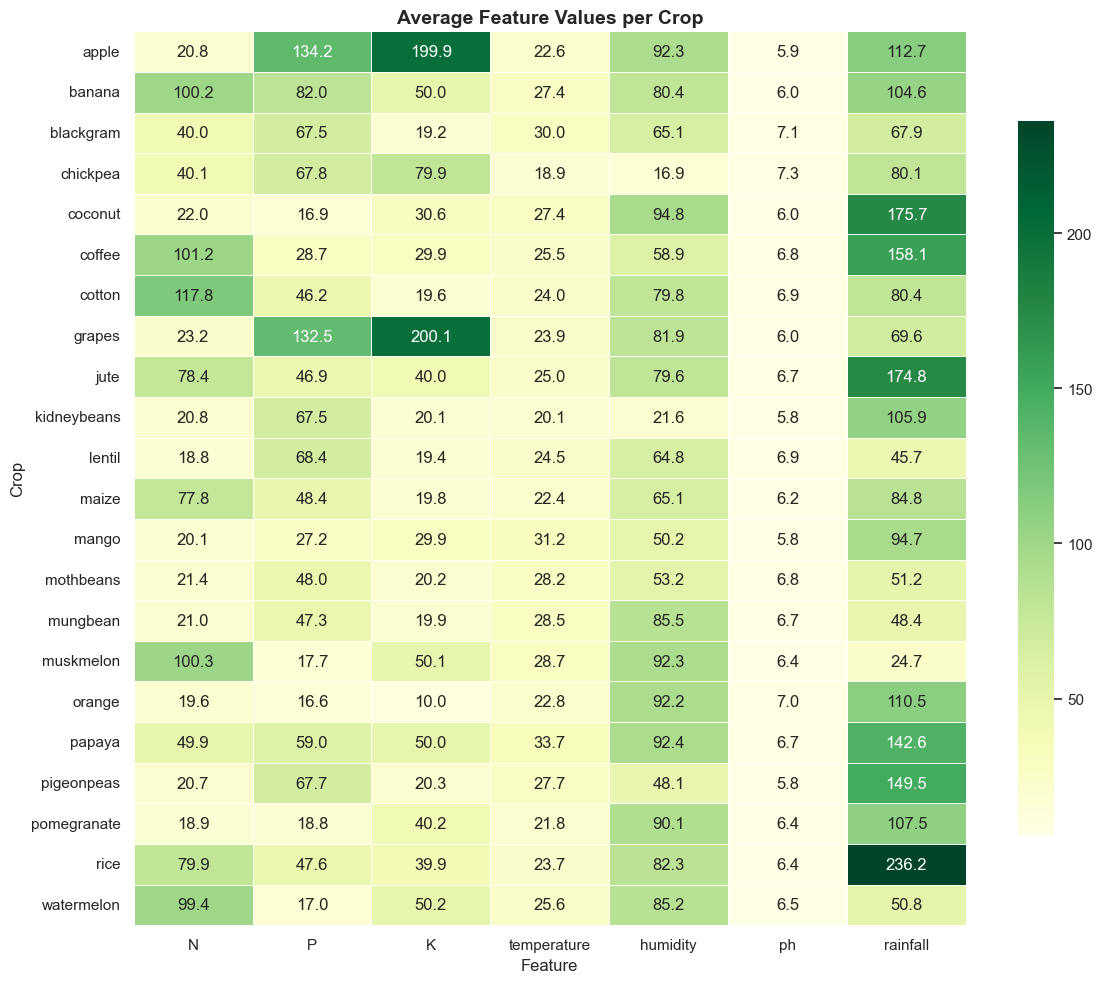

In [13]:
crop_means = df.groupby("label")[features].mean().round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(crop_means, annot=True, fmt=".1f", cmap="YlGn",
            linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.8})
plt.title("Average Feature Values per Crop",
          fontsize=14, fontweight="bold")
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Crop", fontsize=12)
plt.tight_layout()
plt.show()

### 4.5 — Top 5 Crops by Feature

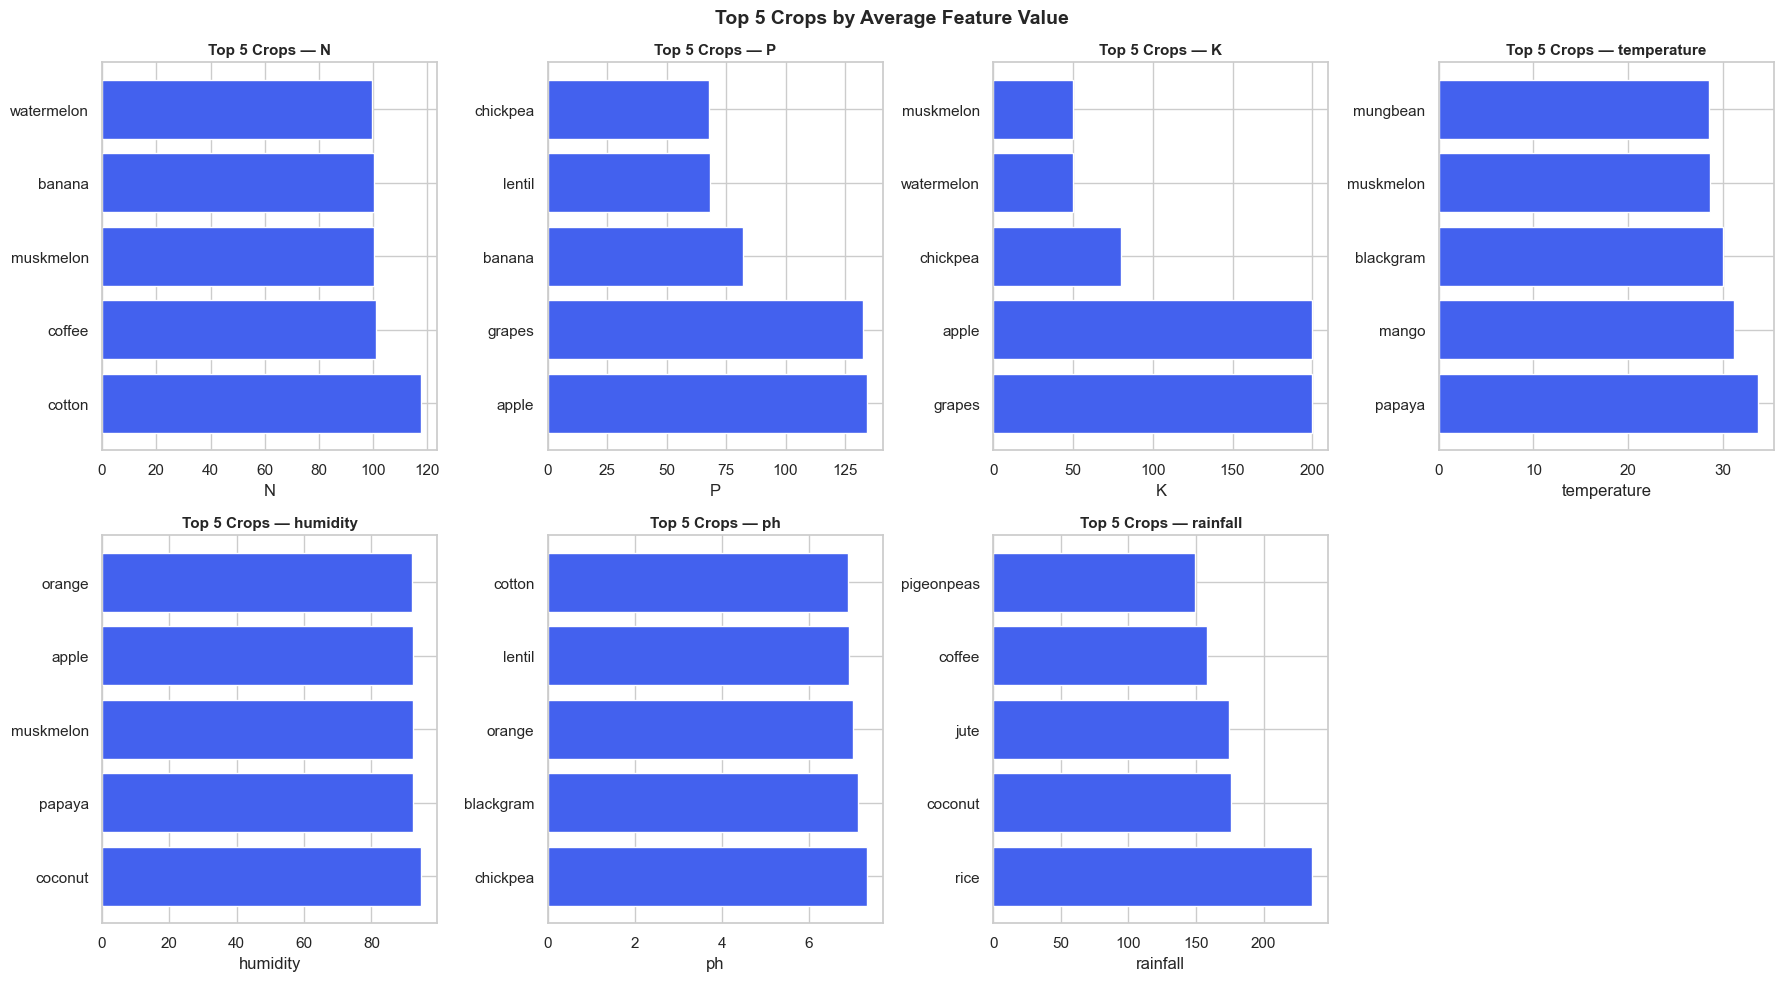

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    top5 = crop_means[feat].nlargest(5)
    axes[i].barh(top5.index, top5.values,
                 color="#4361ee", edgecolor="white")
    axes[i].set_title(f"Top 5 Crops — {feat}",
                      fontsize=11, fontweight="bold")
    axes[i].set_xlabel(feat)

axes[-1].set_visible(False)
plt.suptitle("Top 5 Crops by Average Feature Value",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.6 — Pairplot (N, P, K, pH by Crop Group)

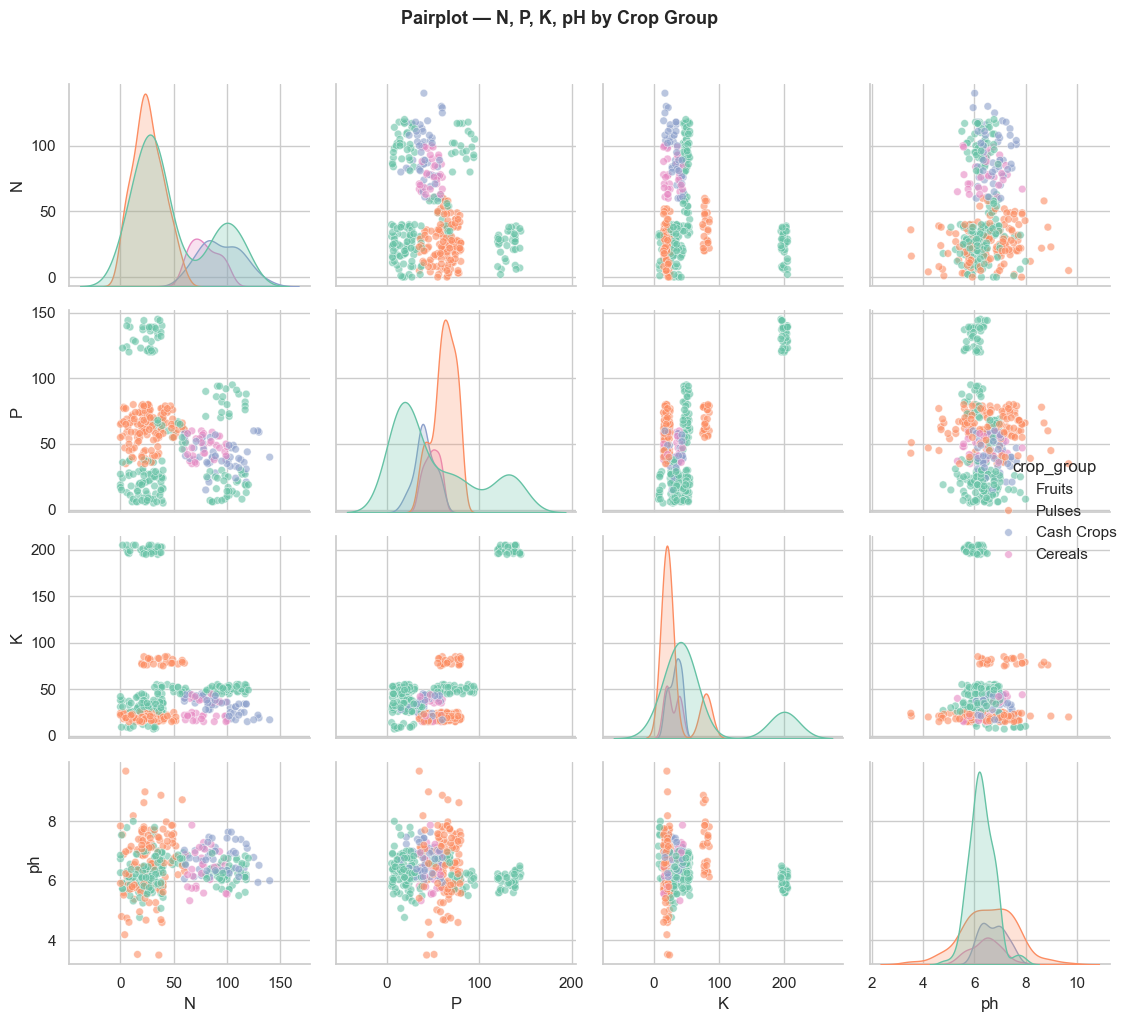

In [15]:
# Group crops for cleaner pairplot visualisation
crop_groups = {
    "Cereals": ["rice","maize"],
    "Fruits": ["apple","banana","mango","grapes","watermelon",
               "muskmelon","papaya","orange","coconut","pomegranate"],
    "Pulses": ["chickpea","kidneybeans","lentil","blackgram",
               "mungbean","mothbeans","pigeonpeas"],
    "Cash Crops": ["cotton","jute","coffee"]
}
group_map = {}
for grp, crops in crop_groups.items():
    for c in crops:
        group_map[c] = grp

df["crop_group"] = df["label"].map(group_map)
sample = df.sample(400, random_state=42)

sns.pairplot(sample[["N","P","K","ph","crop_group"]],
             hue="crop_group", palette="Set2",
             plot_kws={"alpha": 0.6, "s": 30})
plt.suptitle("Pairplot — N, P, K, pH by Crop Group",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

df = df.drop(columns=["crop_group"])

---
## Stage 4 EDA Summary

| Finding | Detail |
|---|---|
| Dataset size | 2,200 rows, 8 columns |
| Missing values | None |
| Duplicates | None |
| Class balance | Perfectly balanced — 100 per crop |
| Unique crops | 22 |
| Key insight 1 | Rice and jute need high rainfall (>200mm) |
| Key insight 2 | Coffee requires high humidity and low K |
| Key insight 3 | Fruits cluster differently from pulses in N-P-K space |
| Key insight 4 | pH is an independent feature — low correlation with others |
| Ready for modelling | Yes — no cleaning required |

> Continue to `02_model.ipynb` for feature engineering, model training, and evaluation.